## Predicción de correos spam 

Este proyecto aborda el problema de la detección automática de correos electrónicos no deseados mediante técnicas de aprendizaje automático. A partir de características cuantificables extraídas del contenido del mensaje —como frecuencias de palabras, uso de caracteres especiales y patrones de mayúsculas— se entrena un modelo de red neuronal capaz de predecir si un correo corresponde a spam o a un mensaje legítimo, con el objetivo de mejorar los sistemas de filtrado y protección del usuario.

## Exploración de datos 

In [26]:
# 1. IMPORTAR LIBRERÍAS 

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Configuración de visualización

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline


In [28]:
# 2. CARGAR LOS DATOS

# Cargar datasets
train = pd.read_csv('spam_train.csv')
test = pd.read_csv('spam_test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

# Cargar nombres de variables 
variable_info = pd.read_csv( 
    'variable_names.txt',
    sep=" ", 
    header=None, 
    names=["index","name"]
)
print(variable_info)

    index                        name
0       1              word_freq_make
1       2           word_freq_address
2       3               word_freq_all
3       4                word_freq_3d
4       5               word_freq_our
5       6              word_freq_over
6       7            word_freq_remove
7       8          word_freq_internet
8       9             word_freq_order
9      10              word_freq_mail
10     11           word_freq_receive
11     12              word_freq_will
12     13            word_freq_people
13     14            word_freq_report
14     15         word_freq_addresses
15     16              word_freq_free
16     17          word_freq_business
17     18             word_freq_email
18     19               word_freq_you
19     20            word_freq_credit
20     21              word_freq_your
21     22              word_freq_font
22     23               word_freq_000
23     24             word_freq_money
24     25                word_freq_hp
25     26   

In [29]:
# 3. ANÁLISIS DIMENSIONAL

print("\n")
print("ANÁLISIS DIMENSIONAL")
print("-"*60)
print(f"Dimensiones train: {train.shape}")
print(f"Dimensiones test: {test.shape}")
print(f"\nNúmero de variables predictoras: {train.shape[1] - 1}")
print(f"Número de observaciones train: {train.shape[0]}")
print(f"Número de observaciones test: {test.shape[0]}")



ANÁLISIS DIMENSIONAL
------------------------------------------------------------
Dimensiones train: (3001, 59)
Dimensiones test: (1600, 58)

Número de variables predictoras: 58
Número de observaciones train: 3001
Número de observaciones test: 1600


In [30]:
# 4. VISTA PREVIA DE LOS DATOS
clean_names = variable_info["name"].str.replace('"','').tolist()
train.columns = ["ID"] + clean_names
test.columns = ["ID"] + clean_names[:-1]

print("\n")
print("PRIMERAS OBSERVACIONES")
print("-"*60)
display(train.head(10))

print("\n")
print("ÚLTIMAS OBSERVACIONES")
print("-"*60)
display(train.tail(10))




PRIMERAS OBSERVACIONES
------------------------------------------------------------


,ID,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,SPAM
0,646,0.00,0.00,0.00,0.0,0.00,0.045,4.08,0.00,0.036,...,0.000,0.00,0.000,0.421,0.126,0.000,4.181,26,46,1
1,3365,0.00,0.00,0.00,0.0,0.00,0.000,0.00,0.00,0.036,...,0.000,0.00,0.000,0.022,0.126,0.000,1.375,6,44,0
2,2992,0.00,0.00,0.00,0.0,0.00,0.224,0.00,0.00,0.036,...,0.377,0.00,0.094,0.000,0.126,0.000,4.807,31,274,0
3,3885,0.00,0.19,0.59,0.0,0.19,0.000,0.00,0.00,0.226,...,0.000,0.00,0.018,0.000,0.126,0.000,3.716,47,472,0
4,818,0.23,0.34,0.58,0.0,0.46,0.233,0.11,0.23,0.036,...,0.000,0.46,0.000,0.376,0.182,0.018,4.470,74,675,1
5,2262,0.18,0.18,0.18,0.0,0.37,0.000,0.00,0.37,0.036,...,0.116,0.00,0.029,0.184,0.155,0.000,3.455,24,387,0
6,2872,0.00,0.00,0.00,0.0,0.00,0.055,0.00,0.00,0.036,...,0.067,0.00,0.000,0.000,0.126,0.000,1.980,59,204,0
7,3403,0.00,0.00,0.00,0.0,0.00,0.000,0.00,1.23,0.036,...,0.000,0.00,0.000,0.121,0.126,0.000,1.300,3,26,0
8,2123,0.00,0.33,0.16,0.0,1.15,0.327,0.16,0.00,0.036,...,0.000,0.00,0.000,0.230,0.202,0.025,3.401,37,364,0
9,2035,0.00,0.00,0.00,0.0,0.00,0.179,0.00,0.00,0.036,...,0.000,0.00,0.000,0.049,0.126,0.000,1.750,5,21,0




ÚLTIMAS OBSERVACIONES
------------------------------------------------------------


,ID,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,SPAM
2991,625,1.65,0.0,0.00,0.0,0.82,0.000,0.00,0.0,0.036,...,0.0,0.00,0.000,0.014,0.126,0.0,1.250,4,50,1
2992,777,0.44,0.0,0.00,0.0,3.98,0.356,0.00,0.0,0.036,...,0.0,0.00,0.000,0.000,0.254,0.0,2.215,23,113,1
2993,1414,0.00,0.0,0.00,0.0,0.00,0.000,0.00,0.0,0.036,...,0.0,0.00,0.000,0.199,0.468,0.0,3.809,24,80,1
2994,2549,0.00,0.0,0.00,0.0,0.00,0.106,0.00,0.0,0.036,...,0.0,0.00,0.000,0.188,0.126,0.0,1.794,6,70,0
2995,749,0.00,0.0,0.34,0.0,0.00,0.217,0.34,0.0,0.036,...,0.0,0.34,0.000,0.122,0.182,0.0,2.257,17,158,1
2996,4530,0.00,0.0,0.00,0.0,0.00,0.059,0.00,0.0,0.036,...,0.0,0.00,0.000,0.227,0.126,0.0,1.117,3,38,0
2997,3818,0.00,0.0,0.00,0.0,0.00,0.000,0.00,0.0,0.886,...,0.0,0.00,0.139,0.000,0.126,0.0,2.138,12,77,0
2998,4295,0.00,0.0,0.37,0.0,1.13,0.000,0.00,0.0,0.036,...,0.0,0.00,0.000,0.106,0.126,0.0,1.264,4,43,0
2999,2486,0.00,0.0,0.00,0.0,0.00,0.000,0.00,2.0,0.036,...,0.0,0.00,0.000,0.000,0.126,0.0,5.888,29,53,0
3000,1497,0.00,0.0,0.00,0.0,1.56,0.000,1.56,0.0,0.036,...,0.0,0.00,0.000,0.638,0.381,0.0,8.083,81,97,1


###  Análisis dimensional
El conjunto de datos de entrenamiento (train) cuenta con 3001 observaciones y 59 columnas, mientras que el conjunto de prueba (test) contiene 1600 observaciones y 58 columnas.  
Este conjunto de entrenamiento incluye 58 variables predictoras y una variable adicional correspondiente a la **clase objetivo (spam o no spam)**

### Vista preliminar de los datos
Se muestra las primeras y últimas observaciones del conjunto de entrenamiento para identificar patrones generales, rangos de valores y posibles anomalías.  
Las variables son de tipo numérico y corresponden a características extraídas del contenido de los correos electrónicos, como frecuencias de palabras específicas, uso de caracteres especiales y métricas relacionadas con mayúsculas.

Se observa que:
- Muchas variables presentan valores cercanos a cero.
- No se evidencian valores faltantes en esta vista preliminar.
- La estructura del conjunto de datos es consistente y adecuada para aplicar técnicas de aprendizaje automático.


In [31]:
# 5. INFORMACIÓN DE TIPOS DE DATOS

print("\n")
print("TIPOS DE DATOS")
print("-"*60)
print(train.info())
print(f"\nTipos de datos únicos: {train.dtypes.value_counts()}")



TIPOS DE DATOS
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3001 entries, 0 to 3000
Data columns (total 59 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          3001 non-null   int64  
 1   word_freq_make              3001 non-null   float64
 2   word_freq_address           3001 non-null   float64
 3   word_freq_all               3001 non-null   float64
 4   word_freq_3d                3001 non-null   float64
 5   word_freq_our               3001 non-null   float64
 6   word_freq_over              3001 non-null   float64
 7   word_freq_remove            3001 non-null   float64
 8   word_freq_internet          3001 non-null   float64
 9   word_freq_order             3001 non-null   float64
 10  word_freq_mail              3001 non-null   float64
 11  word_freq_receive           3001 non-null   float64
 12  word_freq_wi


- **Observación** : No se observan valores nulos en ninguna de las columnas.



ANÁLISIS DE VARIABLE OBJETIVO
------------------------------------------------------------
Variable objetivo: SPAM

Distribución de clases:
SPAM
0    1796
1    1205
Name: count, dtype: int64

Proporción de clases:
SPAM
0    0.598467
1    0.401533
Name: proportion, dtype: float64


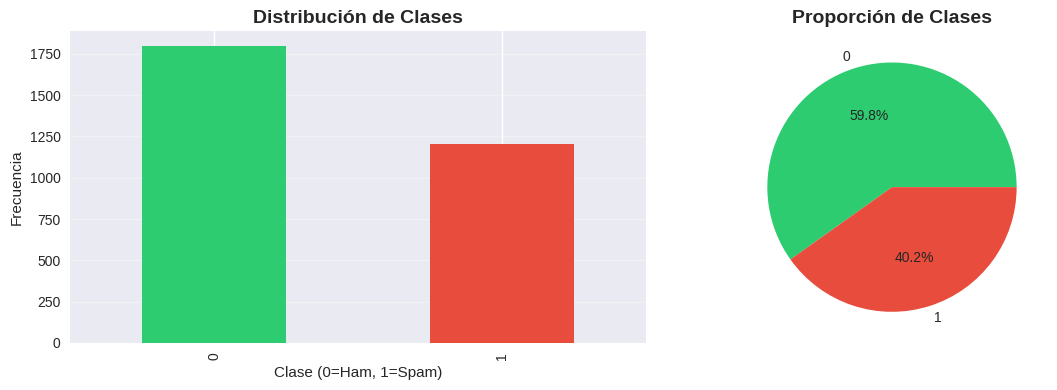

In [32]:
# 6. ANÁLISIS DE VARIABLE OBJETIVO (spam)

print("\n" )
print("ANÁLISIS DE VARIABLE OBJETIVO")
print("-"*60)

# La columna target se llama spam

target_col = train.columns[-1] 
print(f"Variable objetivo: {target_col}")
print(f"\nDistribución de clases:")
print(train[target_col].value_counts())
print(f"\nProporción de clases:")
print(train[target_col].value_counts(normalize=True))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
train[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de Clases', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase (0=Ham, 1=Spam)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)

# Proporción
train[target_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                      colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


### Análisis de la variable objetivo

La variable objetivo corresponde a la clasificación de los correos electrónicos en **mensajes correctos (0 = ham)** y **correos no deseados (1 = spam)**.

La distribución de clases muestra que aproximadamente el **59.8 %** de los correos corresponde a mensajes correctos mientras que el **40.2 %** corresponde a spam. Esto indica un ligero desbalance de clases.


In [33]:

# 7. ESTADÍSTICAS DESCRIPTIVAS

print("\n")
print("ESTADÍSTICAS DESCRIPTIVAS")
print("-"*60)
stats_desc = train.describe().T
stats_desc['cv'] = stats_desc['std'] / stats_desc['mean']  # Coeficiente de variación
stats_desc['rango'] = stats_desc['max'] - stats_desc['min']
display(stats_desc)



ESTADÍSTICAS DESCRIPTIVAS
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max,cv,rango
ID,3001.0,2284.139287,1337.572037,1.000,1113.000,2278.000,3426.000,4601.000,0.585591,4600.000
word_freq_make,3001.0,0.098570,0.339230,0.000,0.000,0.000,0.000,6.060,3.441500,6.060
word_freq_address,3001.0,0.216348,1.300497,0.000,0.000,0.000,0.000,14.280,6.011137,14.280
word_freq_all,3001.0,0.280920,0.497393,0.000,0.000,0.000,0.430,5.100,1.770588,5.100
word_freq_3d,3001.0,0.088704,1.700779,0.000,0.000,0.000,0.000,42.810,19.173693,42.810
word_freq_our,3001.0,0.322706,0.706823,0.000,0.000,0.000,0.400,10.000,2.190300,10.000
word_freq_over,3001.0,0.150202,0.272827,0.000,0.000,0.054,0.192,3.609,1.816395,3.609
word_freq_remove,3001.0,0.112929,0.377867,0.000,0.000,0.000,0.000,7.270,3.346056,7.270
word_freq_internet,3001.0,0.111876,0.323354,0.000,0.000,0.000,0.000,4.340,2.890285,4.340
word_freq_order,3001.0,0.161871,0.556893,0.036,0.036,0.036,0.036,9.126,3.440341,9.090


### Estadísticas descriptivas

La mayoría de las variables presentan medias bajas y medianas cercanas a cero, lo cual es consistente con su interpretación como frecuencias de aparición de palabras y patrones en los correos electrónicos. Asimismo, se observa una asimetría positiva, evidenciada por valores máximos considerablemente mayores que los cuartiles superiores.

El coeficiente de variación  indica una alta variabilidad relativa en varias variables, lo que sugiere la presencia de valores extremos poco frecuentes pero informativos, característicos de este tipo de datos textuales transformados en variables numéricas.


In [34]:
# 8. ANÁLISIS DE VALORES FALTANTES

print("ANÁLISIS DE VALORES FALTANTES")
print("-"*60)

missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

if missing_train.sum() > 0:
    print(f"Total de valores faltantes en TRAIN: {missing_train.sum()}")
    print("\nVariables con valores faltantes:")
    print(missing_train[missing_train > 0])
else:
    print("No hay valores faltantes en el dataset de entrenamiento")

if missing_test.sum() > 0:
    print(f"\nTotal de valores faltantes en TEST: {missing_test.sum()}")
else:
    print("No hay valores faltantes en el dataset de prueba")

ANÁLISIS DE VALORES FALTANTES
------------------------------------------------------------
No hay valores faltantes en el dataset de entrenamiento
No hay valores faltantes en el dataset de prueba




ANÁLISIS DE VALORES ATÍPICOS
------------------------------------------------------------

Variables con outliers (top 10):


,Variable,Outliers,Porcentaje
25,word_freq_hp,711,23.69%
8,word_freq_internet,706,23.53%
17,word_freq_business,657,21.89%
45,word_freq_re,635,21.16%
18,word_freq_email,608,20.26%
2,word_freq_address,605,20.16%
13,word_freq_people,582,19.39%
10,word_freq_mail,560,18.66%
1,word_freq_make,557,18.56%
41,word_freq_cs,549,18.29%


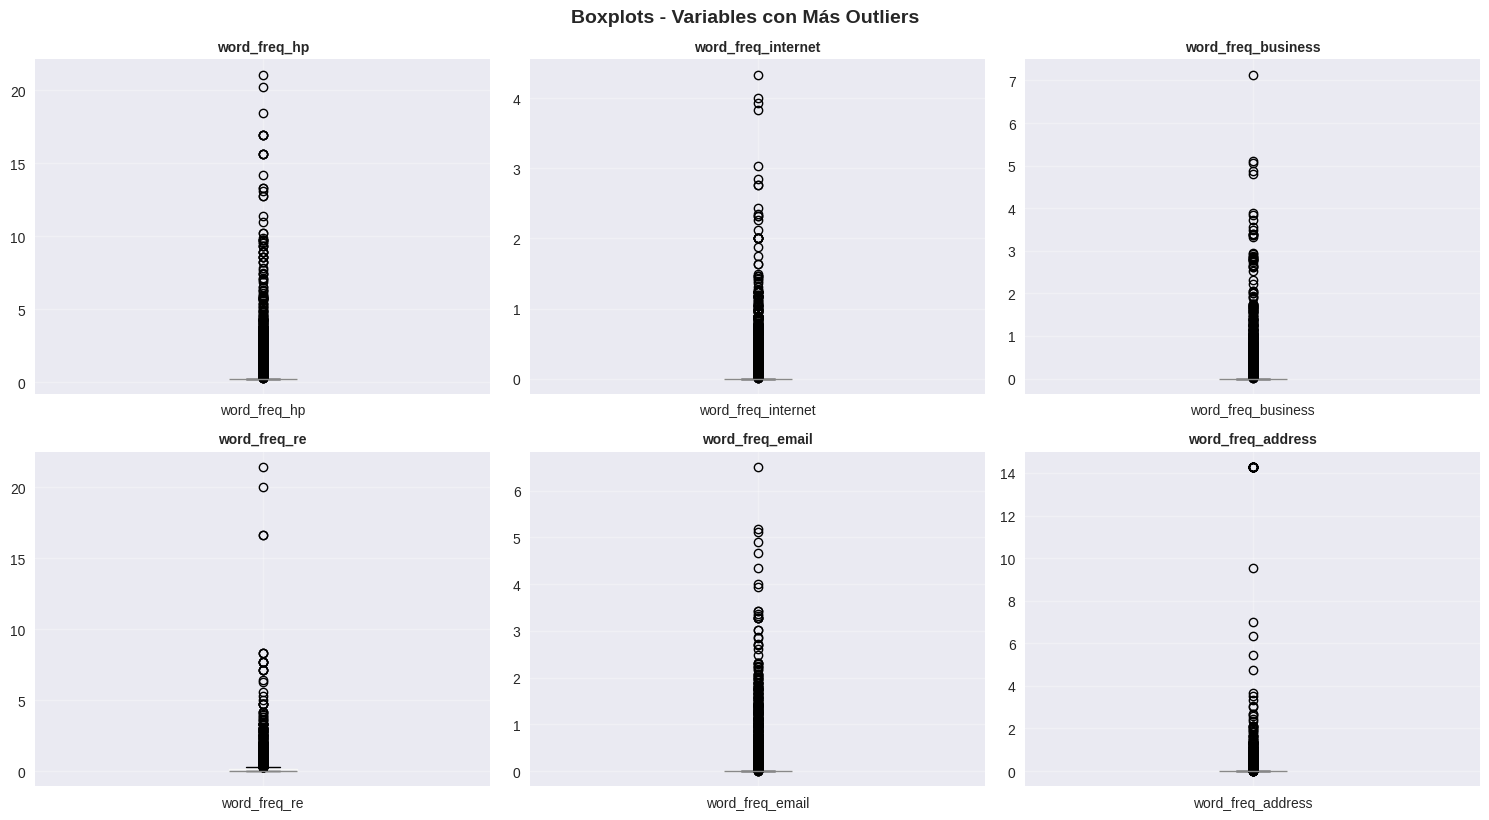

In [35]:
# 9. DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS)

print("\n")
print("ANÁLISIS DE VALORES ATÍPICOS")
print("-"*60)

# Seleccionar solo variables numéricas (excluyendo el target)
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# Calcular outliers usando IQR
outlier_summary = []
for col in numeric_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((train[col] < lower_bound) | (train[col] > upper_bound)).sum()
    outlier_pct = (outliers / len(train)) * 100
    outlier_summary.append({
        'Variable': col,
        'Outliers': outliers,
        'Porcentaje': f"{outlier_pct:.2f}%"
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df[outlier_df['Outliers'] > 0].sort_values('Outliers', ascending=False)
print(f"\nVariables con outliers (top 10):")
display(outlier_df.head(10))

# Boxplot de variables con más outliers
top_outlier_vars = outlier_df.head(6)['Variable'].tolist()
if len(top_outlier_vars) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()
    
    for idx, var in enumerate(top_outlier_vars):
        train.boxplot(column=var, ax=axes[idx])
        axes[idx].set_title(f'{var}', fontsize=10, fontweight='bold')
        axes[idx].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Boxplots - Variables con Más Outliers', y=1.02, fontsize=14, fontweight='bold')
    plt.show()

### Análisis de valores atípicos

El análisis de valores atípicos muestra que varias variables presentan una alta proporción de observaciones extremas, como:

- V25 – word_freq_hp  
- V8 – word_freq_internet 
- V17 – word_freq_business 
- V45 – word_freq_re 
- V18 – word_freq_email
- V2 – word_freq_address  
- V13 – word_freq_people 
- V10 – word_freq_mail 
- V1 – word_freq_make
- V41 – word_freq_cs

Estas variables presentan porcentajes de outliers cercanos o superiores al **20 %**, lo cual indica una fuerte presencia de valores extremos.

Los boxplots evidencian una marcada asimetría positiva, donde la mayoría de los correos presenta valores bajos y un número reducido concentra valores elevados. Este comportamiento es coherente con variables que miden frecuencias de palabras específicas, las cuales aparecen de forma esporádica pero intensa en correos spam.

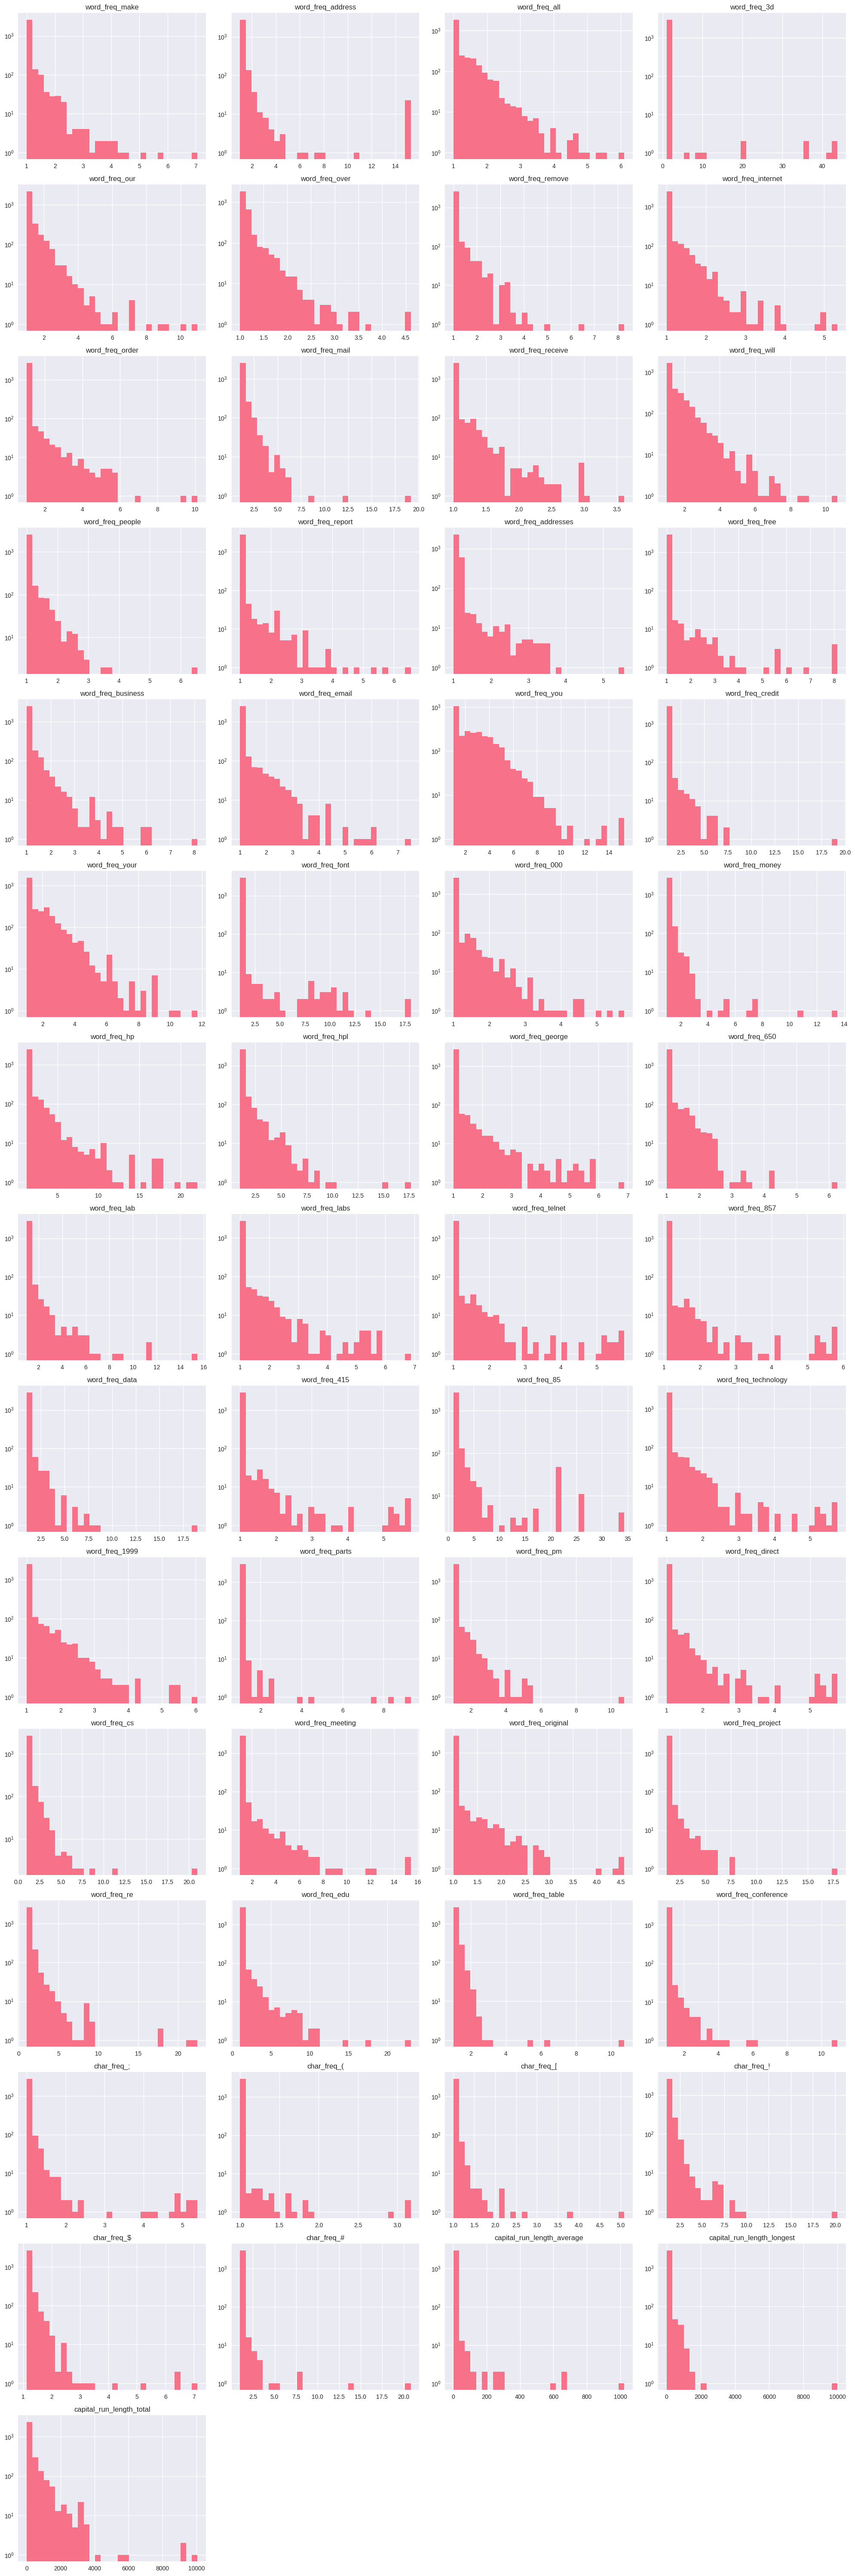

In [37]:
ncols = 4
X = train.drop(columns=["ID", "SPAM"])
# Calcular cuántas filas necesitamos
n_plots = len(X.columns)
nrows = math.ceil(n_plots / ncols)

# Crear la figura y los ejes
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, 
                         figsize=(5*ncols, 4*nrows), 
                         sharey=False)  # sharey=False porque cada histograma tiene su propia escala

# Aplanar el array de axes para recorrerlo fácilmente
axes = axes.flatten()

# Generar cada histograma
for i, col in enumerate(X.columns):
    axes[i].hist(X[col] + 1, bins=30)
    axes[i].set_yscale("log")
    axes[i].set_title(col)
    
# Ocultar los ejes que no se usen (si hay menos plots que celdas)
for i in range(len(X.columns), len(axes)):
    axes[i].axis('off')

# Ajustar espaciado entre gráficos
plt.tight_layout()
plt.show()


### Distribución de variables 

En la figura se muestra las distribuciones de las variabels con el objetivo de analizar la forma, dispersión y concentración de los valores. Se usa escala logarítmica en el eje y para observar mejor la distribución

Las variables asociadas a frecuencias de palabras y patrones en correos electrónicos, muestran distribuciones fuertemente asimétricas a la derecha, con una alta concentración de valores cercanos a cero y colas largas hacia valores mayores. Este comportamiento indica que la mayoría de los correos no contiene dichas palabras, mientras que un número reducido presenta frecuencias elevadas.





ANÁLISIS DE CORRELACIONES
------------------------------------------------------------


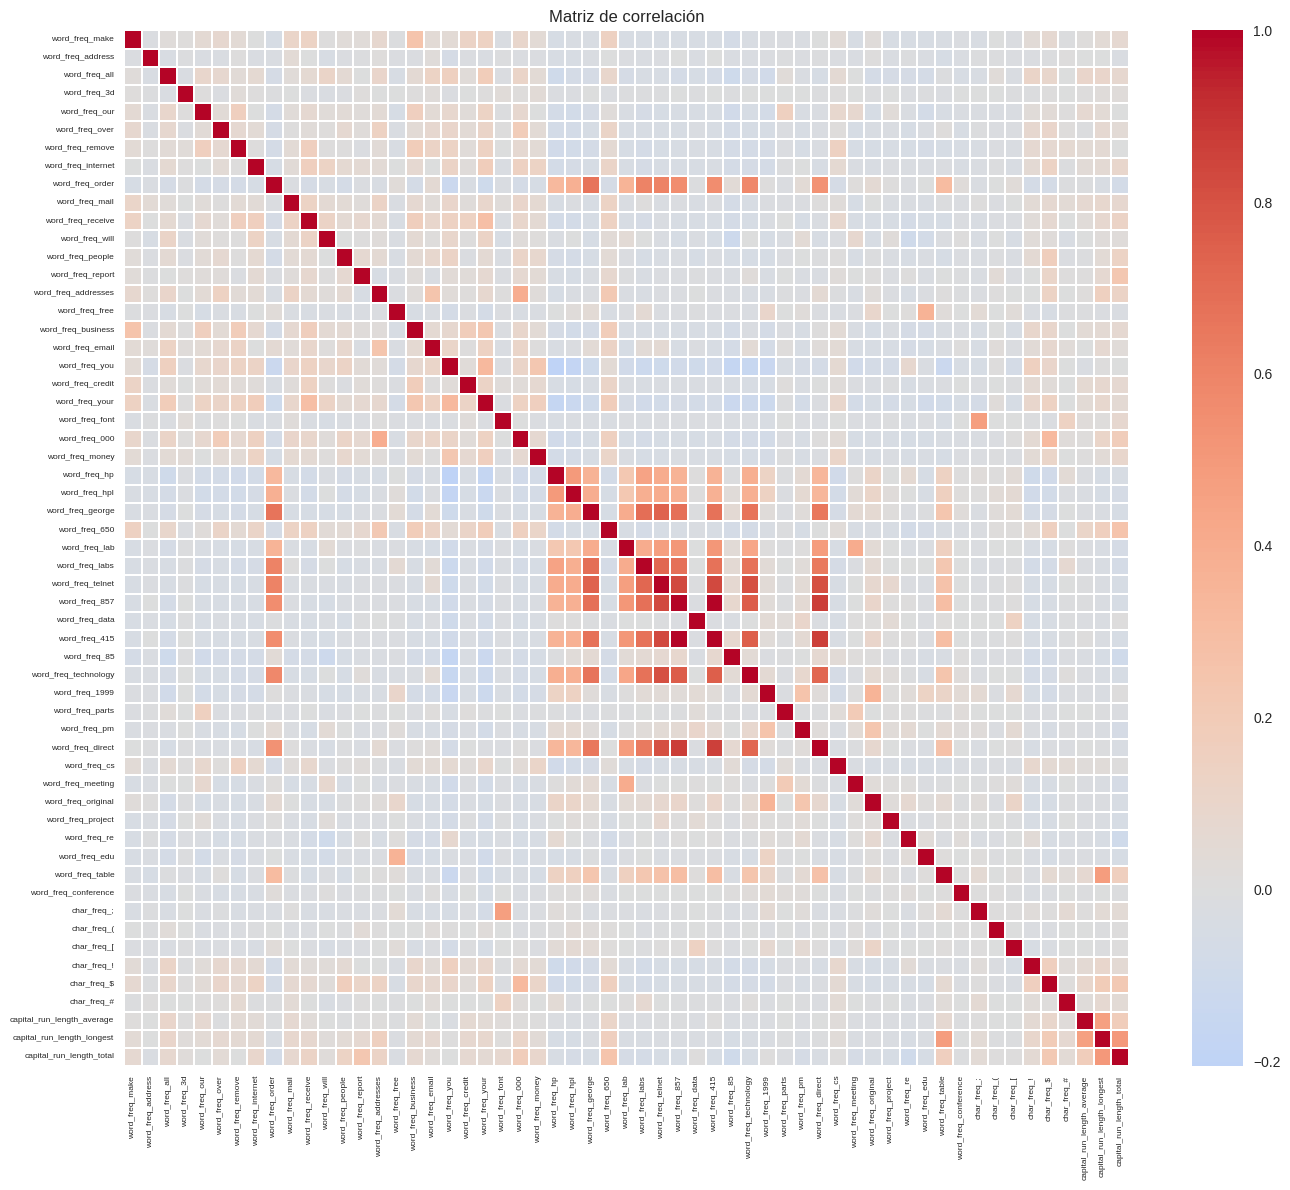

In [40]:
# 11. ANÁLISIS DE CORRELACIONES

print("\n")
print("ANÁLISIS DE CORRELACIONES")
print("-"*60)


corr = X.corr()



plt.figure(figsize=(14, 12))

sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)

plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6, rotation=0)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()


Top 10 variables más correlacionadas con SPAM:
word_freq_your              0.375067
word_freq_remove            0.340901
word_freq_000               0.329733
char_freq_$                 0.321866
word_freq_you               0.287996
char_freq_!                 0.271784
word_freq_business          0.257782
capital_run_length_total    0.254012
word_freq_cs                0.238823
word_freq_650               0.237509
Name: SPAM, dtype: float64

Top 10 variables menos correlacionadas con SPAM:
word_freq_original   -0.138735
word_freq_order      -0.148105
word_freq_edu        -0.149579
word_freq_george     -0.170239
word_freq_labs       -0.175580
word_freq_1999       -0.175709
word_freq_85         -0.180945
word_freq_hpl        -0.230590
word_freq_hp         -0.258086
ID                   -0.848833
Name: SPAM, dtype: float64


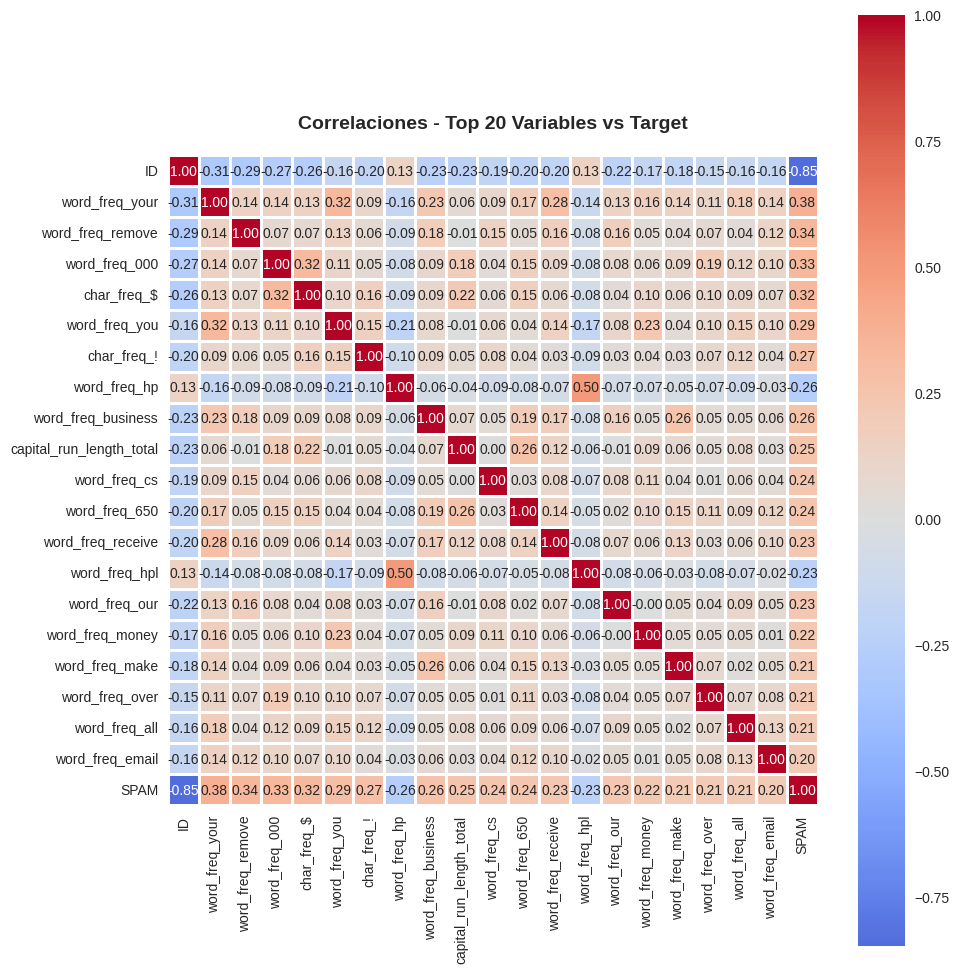

In [41]:

# Matriz de correlación
correlation_matrix = train[numeric_cols + [target_col]].corr()

# Top correlaciones con el target
target_correlations = correlation_matrix[target_col].drop(target_col).sort_values(ascending=False)
print(f"\nTop 10 variables más correlacionadas con {target_col}:")
print(target_correlations.head(10))

print(f"\nTop 10 variables menos correlacionadas con {target_col}:")
print(target_correlations.tail(10))

# Heatmap de correlaciones con el target
plt.figure(figsize=(10, 12))
top_corr_vars = target_correlations.abs().sort_values(ascending=False).head(20).index
corr_subset = train[list(top_corr_vars) + [target_col]].corr()

sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlaciones - Top 20 Variables vs Target', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Análisis de correlación con la variable objetivo

El mapa de calor muestra las correlaciones entre las 20 variables con mayor relación y la variable objetivo (**V58 – clase spam**), permitiendo identificar qué características están más asociadas.

Se observa que la mayoría de las variables presenta correlaciones moderadas. Entre las variables con mayor correlación positiva con la clase spam destacan:

- V21 – word_freq_free
- V7 – word_freq_remove
- V23 – word_freq_money
- V53 – capital_run_length_average
- V19 – word_freq_business
- V52 – char_freq_$
Estas variables están asociadas a términos y patrones típicamente presentes en correos spam, lo que refuerza su relevancia predictiva.

Por otro lado, algunas variables presentan correlaciones negativas con la clase objetivo, como:

- V25 – word_freq_hp
- V17 – word_freq_meeting

Lo cual esta relacionado con una  asociación de correos correctos.



COMPARACIÓN ENTRE SPAM Y HAM
------------------------------------------------------------

Top 10 variables con mayor diferencia (Spam - Ham):


,Spam_Mean,Ham_Mean,Diferencia,Ratio
capital_run_length_total,476.698755,170.218820,306.479936,2.800504
capital_run_length_longest,106.810788,18.433742,88.377047,5.794277
capital_run_length_average,9.130566,2.420170,6.710396,3.772540
word_freq_you,2.305552,1.268753,1.036799,1.817037
word_freq_your,1.380598,0.456765,0.923832,3.021894
word_freq_cs,0.481402,0.079315,0.402087,6.061847
char_freq_!,0.540773,0.152315,0.388457,3.548024
word_freq_our,0.520398,0.190067,0.330332,2.736536
word_freq_remove,0.270166,0.007433,0.262733,35.863447
word_freq_business,0.295344,0.052422,0.242922,5.623246


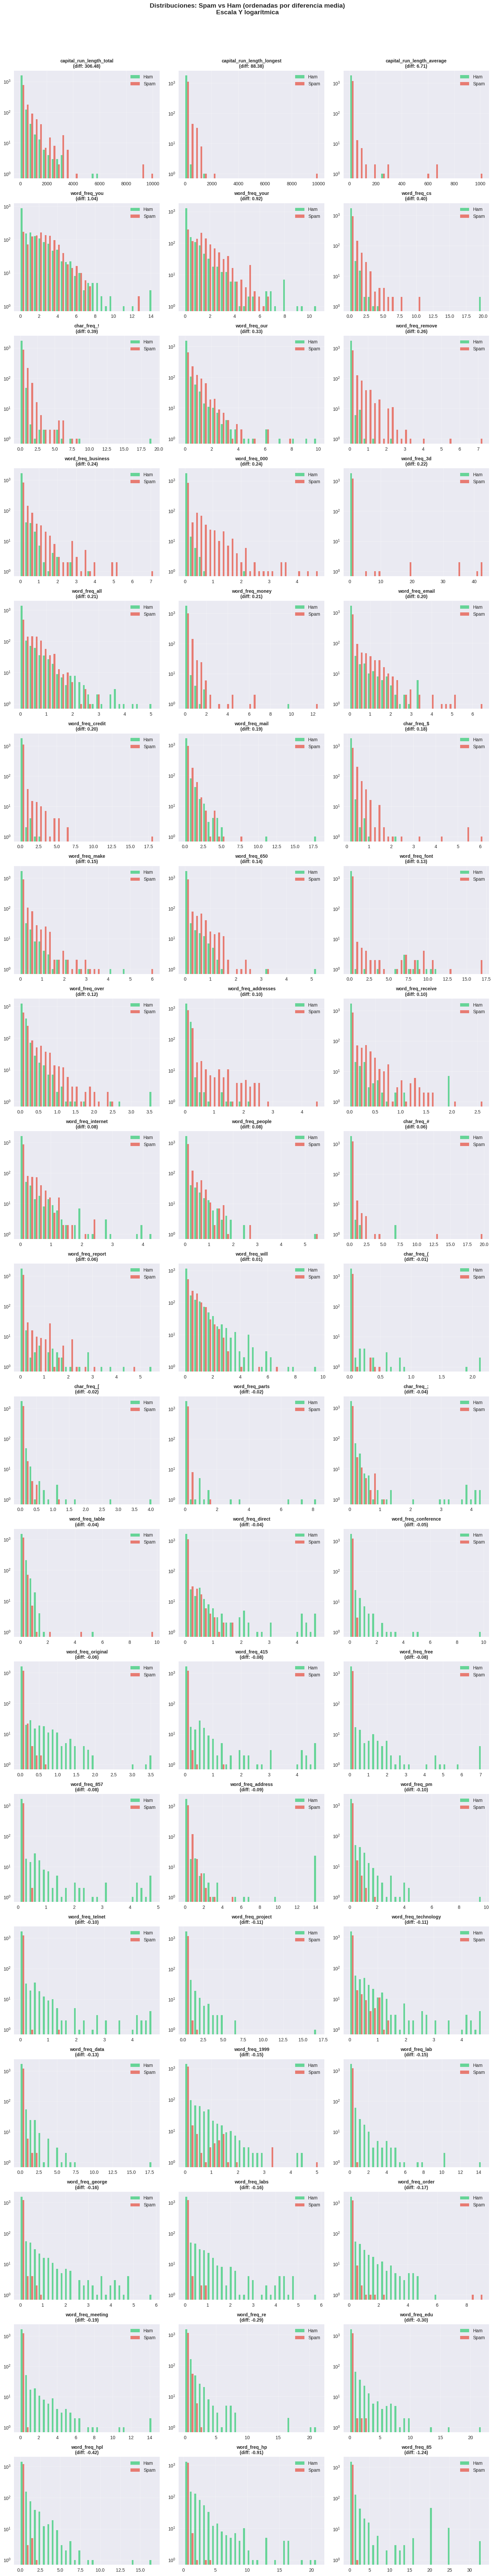

In [45]:
# 12. COMPARACIÓN SPAM VS HAM

print("\n")
print("COMPARACIÓN ENTRE SPAM Y HAM")
print("-"*60)

# Comparar estadísticas descriptivas por clase
spam_stats = train[train[target_col] == 1][numeric_cols].mean().sort_values(ascending=False)
ham_stats = train[train[target_col] == 0][numeric_cols].mean().sort_values(ascending=False)

comparison = pd.DataFrame({
    'Spam_Mean': spam_stats,
    'Ham_Mean': ham_stats,
    'Diferencia': spam_stats - ham_stats,
    'Ratio': spam_stats / (ham_stats + 0.0001)  # Evitar división por 0
})

# Ordenamos por la diferencia (de mayor a menor)
comparison = comparison.sort_values('Diferencia', ascending=False)

# Excluimos la columna 'ID' (si existe)
if 'ID' in comparison.index:
    comparison = comparison.drop('ID')

print("\nTop 10 variables con mayor diferencia (Spam - Ham):")
display(comparison.head(10))

# ────────────────────────────────────────────────────────────────
# Visualización de TODAS las variables (excepto ID), ordenadas por diferencia
# ────────────────────────────────────────────────────────────────

# Todas las variables ordenadas, sin 'ID'
all_vars = [var for var in comparison.index if var != 'ID']

n_vars = len(all_vars)

# Grid: 3 columnas, filas necesarias
ncols = 3
nrows = (n_vars + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, 
                         figsize=(5 * ncols, 4 * nrows), 
                         sharey=False)

# Aplanamos axes para iterar fácilmente
axes = axes.flatten()

for idx, var in enumerate(all_vars):
    spam_data = train[train[target_col] == 1][var]
    ham_data = train[train[target_col] == 0][var]
    
    # Histograma comparativo
    axes[idx].hist([ham_data, spam_data], 
                   bins=30, 
                   label=['Ham', 'Spam'], 
                   alpha=0.7, 
                   color=['#2ecc71', '#e74c3c'])
    
    # Escala logarítmica en Y
    axes[idx].set_yscale('log')
    
    # Título con la diferencia
    diff = comparison.loc[var, 'Diferencia']
    axes[idx].set_title(f'{var}\n(diff: {diff:.2f})', 
                        fontsize=10, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

# Ocultar subplots sobrantes
for idx in range(n_vars, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.suptitle('Distribuciones: Spam vs Ham (ordenadas por diferencia media)\nEscala Y logarítmica', 
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

### Comparación de distribuciones: Spam vs Ham

Se comparan las distribuciones de algunas de las variables más relevantes entre correos **correctos (ham)** y **no deseados (spam)**, con el objetivo de identificar diferencias en su comportamiento según la clase.

Las variables analizadas corresponden principalmente a frecuencias de palabras y métricas relacionadas con el uso de mayúsculas, entre las que se destacan:

- V57 – capital_run_length_total
- V56 – capital_run_length_longest
- V55 – capital_run_length_average
- V19 – word_freq_business
- V21 – word_freq_free
- V41 – word_freq_cs

En general, se observa que los correos spam presentan **valores más elevados y colas más largas** en comparación con los correos correctos, especialmente en las variables asociadas al uso intensivo de mayúsculas y a términos promocionales como *free* o *business*. Por el contrario, los correos ham tienden a concentrarse en valores cercanos a cero.


## Preparación de datos 

In [15]:

# 2.1 CARGAR DATOS

print("\n")
print("2.1 CARGANDO DATOS")
print("-"*60)

train = pd.read_csv('spam_train.csv')
test = pd.read_csv('spam_test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print(f"✓ Train shape: {train.shape}")
print(f"✓ Test shape: {test.shape}")

# Separar features y target
X = train.drop(columns=['V58'])  # V58 es la variable objetivo
y = train['V58']
X_test = test.copy()

print(f"\n✓ Features (X): {X.shape}")
print(f"✓ Target (y): {y.shape}")
print(f"✓ Test set: {X_test.shape}")



2.1 CARGANDO DATOS
------------------------------------------------------------
✓ Train shape: (3001, 59)
✓ Test shape: (1600, 58)

✓ Features (X): (3001, 58)
✓ Target (y): (3001,)
✓ Test set: (1600, 58)


In [16]:

# 2.2 DIVISIÓN TRAIN/VALIDATION

print("\n")
print("2.2 DIVISIÓN TRAIN/VALIDATION")
print("-"*60)

# Dividir en train y validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Mantener proporciones de clase
)

print(f"✓ X_train: {X_train.shape}")
print(f"✓ X_val: {X_val.shape}")
print(f"✓ y_train: {y_train.shape}")
print(f"✓ y_val: {y_val.shape}")

print(f"\nDistribución en Train:")
print(y_train.value_counts(normalize=True))
print(f"\nDistribución en Validation:")
print(y_val.value_counts(normalize=True))



2.2 DIVISIÓN TRAIN/VALIDATION
------------------------------------------------------------
✓ X_train: (2400, 58)
✓ X_val: (601, 58)
✓ y_train: (2400,)
✓ y_val: (601,)

Distribución en Train:
V58
0    0.598333
1    0.401667
Name: proportion, dtype: float64

Distribución en Validation:
V58
0    0.599002
1    0.400998
Name: proportion, dtype: float64


In [17]:

# 2.3 MANEJO DE OUTLIERS (OPCIONAL)

print("\n")
print("2.3 ESTRATEGIAS PARA OUTLIERS")
print("-"*60)

"""CLIPPING : Limitar valores extremos sin eliminarlos
"""

# Clipping (
def clip_outliers(df, columns=None, n_std=3):

    df_clipped = df.copy()
    if columns is None:
        columns = df.columns
    
    for col in columns:
        mean = df[col].mean()
        std = df[col].std()
        lower = mean - n_std * std
        upper = mean + n_std * std
        df_clipped[col] = df[col].clip(lower, upper)
    
    return df_clipped

# Aplicar clipping (OPCIONAL )
X_train_clipped = clip_outliers(X_train)
X_val_clipped = clip_outliers(X_val)
X_test_clipped = clip_outliers(X_test)





2.3 ESTRATEGIAS PARA OUTLIERS
------------------------------------------------------------




2.4 ESCALAMIENTO DE VARIABLES
------------------------------------------------------------
✓ 3 estrategias de escalamiento aplicadas:
  1. StandardScaler (Z-score)
  2. RobustScaler (recomendado) ✓
  3. MinMaxScaler (0-1)

✓ Scaler seleccionado: RobustScaler


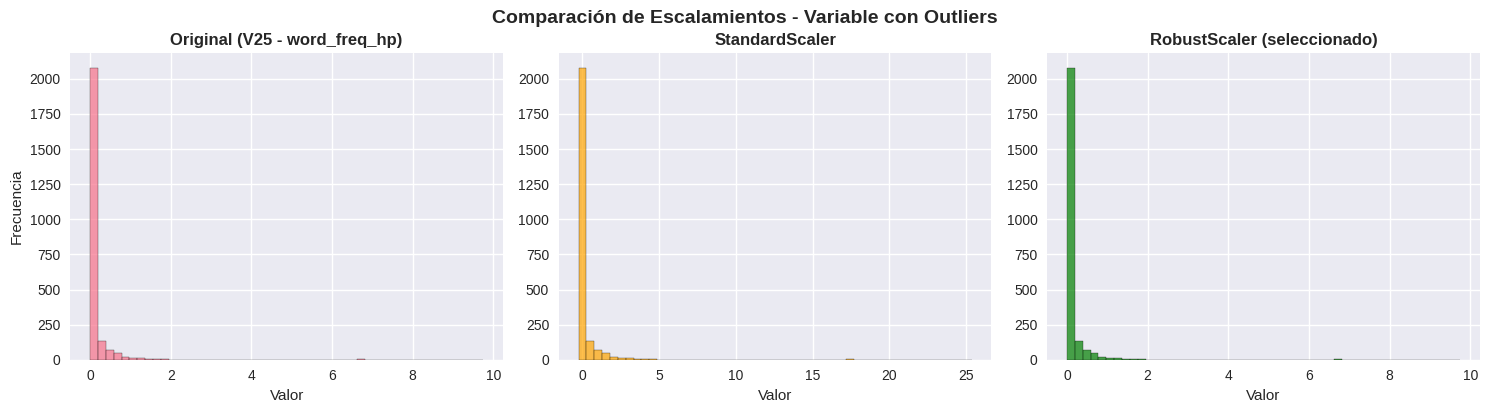

In [19]:

# 2.4 ESCALAMIENTO DE VARIABLES
print("\n" )
print("2.4 ESCALAMIENTO DE VARIABLES")
print("-"*60)

"""
CRÍTICO PARA REDES NEURONALES:
- StandardScaler: media=0, std=1 (sensible a outliers)
- RobustScaler: usa mediana y IQR (robusto a outliers) 
- MinMaxScaler: escala a [0,1] (muy sensible a outliers)
"""

# OPCIÓN 1: StandardScaler
scaler_standard = StandardScaler()
X_train_std = scaler_standard.fit_transform(X_train)
X_val_std = scaler_standard.transform(X_val)
X_test_std = scaler_standard.transform(X_test)

# OPCIÓN 2: RobustScaler (RECOMENDADO por outliers)
scaler_robust = RobustScaler()
X_train_robust = scaler_robust.fit_transform(X_train)
X_val_robust = scaler_robust.transform(X_val)
X_test_robust = scaler_robust.transform(X_test)

# OPCIÓN 3: MinMaxScaler
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_val_minmax = scaler_minmax.transform(X_val)
X_test_minmax = scaler_minmax.transform(X_test)

print("✓ 3 estrategias de escalamiento aplicadas:")
print("  1. StandardScaler (Z-score)")
print("  2. RobustScaler (recomendado) ✓")
print("  3. MinMaxScaler (0-1)")

# Usaremos RobustScaler como principal
X_train_scaled = X_train_robust
X_val_scaled = X_val_robust
X_test_scaled = X_test_robust
selected_scaler = scaler_robust

print(f"\n✓ Scaler seleccionado: RobustScaler")

# Visualizar efecto del escalamiento
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Variable con muchos outliers (V25)
var_idx = 24  # V25 (índice 24)

axes[0].hist(X_train.iloc[:, var_idx], bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('Original (V25 - word_freq_hp)', fontweight='bold')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(X_train_std[:, var_idx], bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1].set_title('StandardScaler', fontweight='bold')
axes[1].set_xlabel('Valor')

axes[2].hist(X_train_robust[:, var_idx], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[2].set_title('RobustScaler (seleccionado)', fontweight='bold')
axes[2].set_xlabel('Valor')

plt.tight_layout()
plt.suptitle('Comparación de Escalamientos - Variable con Outliers', y=1.02, fontsize=14, fontweight='bold')
plt.show()



In [20]:


# 2.5 MANEJO DE DESBALANCEO DE CLASES

print("\n")
print("2.5 MANEJO DE DESBALANCEO DE CLASES")
print("-"*60)

print(f"Distribución original:")
print(f"  Ham (0): {(y_train == 0).sum()} ({(y_train == 0).mean():.1%})")
print(f"  Spam (1): {(y_train == 1).sum()} ({(y_train == 1).mean():.1%})")


# OPCIÓN 1: Class Weights (lo usaremos en el modelo)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"\n✓ Class weights calculados: {class_weight_dict}")

# OPCIÓN 2: SMOTE (generar muestras sintéticas)
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\nCon SMOTE:")
print(f"  Nuevas dimensiones: {X_train_smote.shape}")
print(f"  Ham: {(y_train_smote == 0).sum()}")
print(f"  Spam: {(y_train_smote == 1).sum()}")

# OPCIÓN 3: SMOTETomek (SMOTE + limpieza)
smote_tomek = SMOTETomek(random_state=42)
X_train_smotetomek, y_train_smotetomek = smote_tomek.fit_resample(X_train_scaled, y_train)

print(f"\nCon SMOTE+Tomek:")
print(f"  Nuevas dimensiones: {X_train_smotetomek.shape}")
print(f"  Ham: {(y_train_smotetomek == 0).sum()}")
print(f"  Spam: {(y_train_smotetomek == 1).sum()}")

print("\n✓ Estrategia recomendada: Class Weights (más conservador)")
print("  Alternativas disponibles: SMOTE, SMOTE+Tomek")



2.5 MANEJO DE DESBALANCEO DE CLASES
------------------------------------------------------------
Distribución original:
  Ham (0): 1436 (59.8%)
  Spam (1): 964 (40.2%)

✓ Class weights calculados: {0: np.float64(0.8356545961002786), 1: np.float64(1.2448132780082988)}

Con SMOTE:
  Nuevas dimensiones: (2872, 58)
  Ham: 1436
  Spam: 1436

Con SMOTE+Tomek:
  Nuevas dimensiones: (2854, 58)
  Ham: 1427
  Spam: 1427

✓ Estrategia recomendada: Class Weights (más conservador)
  Alternativas disponibles: SMOTE, SMOTE+Tomek
